# RFM 用户分群 & K-Means 聚类

**业务问题**：我们的用户价值分布是怎样的？如何识别高价值用户和流失风险用户？

**方法**：SQL 驱动的 RFM 打分 + Python K-Means 聚类交叉验证

In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import config
import sqlite3
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── 先把 seaborn 风格设好 ──
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

# ── 再设中文字体（必须放在 sns.set_style 之后！否则会被覆盖）──
import matplotlib.font_manager as fm
import glob
_cache_dir = matplotlib.get_cachedir()
for _f in glob.glob(os.path.join(_cache_dir, 'fontlist*.json')):
    try: os.remove(_f)
    except: pass
fm._load_fontmanager(try_read_cache=False)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Noto Sans SC']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

from src.analysis import run_rfm_analysis, rfm_kmeans_clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1. SQL RFM 分群结果

In [5]:
rfm = run_rfm_analysis()
rfm

,用户群体,用户数,平均距今天数,平均购买次数,人均消费,群体总收入,人数占比
0,高价值用户,15356,94.2,1.0,295.87,4543346.33,16.5
1,一般用户,33563,231.9,1.0,130.86,4391953.22,36.0
2,流失风险用户,14595,397.2,1.0,300.69,4388585.83,15.6
3,已流失用户,15382,399.0,1.0,54.79,842830.97,16.5
4,新用户,14367,92.5,1.0,53.72,771770.24,15.4


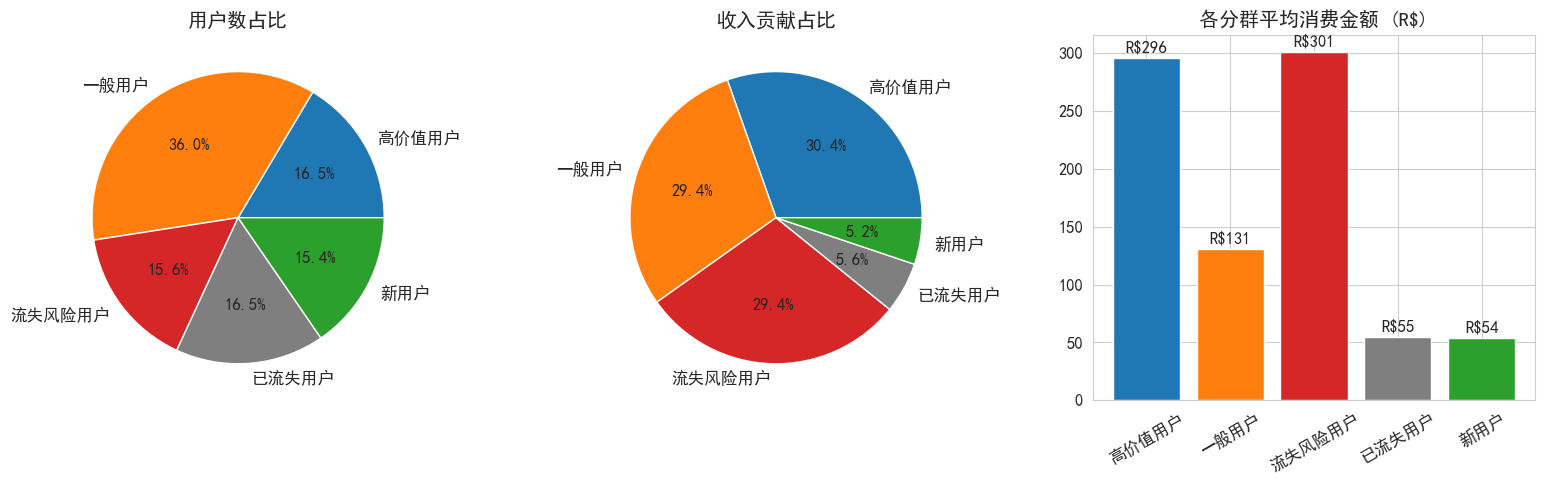

In [6]:
# 可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_seg = {
    '高价值用户': '#1f77b4',
    '新用户': '#2ca02c',
    '一般用户': '#ff7f0e',
    '流失风险用户': '#d62728',
    '已流失用户': '#7f7f7f'
}
seg_colors = [colors_seg.get(s, '#7f7f7f') for s in rfm['用户群体']]

# 用户数占比
axes[0].pie(rfm['用户数'], labels=rfm['用户群体'], autopct='%1.1f%%', colors=seg_colors)
axes[0].set_title('用户数占比')

# 收入占比
axes[1].pie(rfm['群体总收入'], labels=rfm['用户群体'], autopct='%1.1f%%', colors=seg_colors)
axes[1].set_title('收入贡献占比')

# 平均消费
bars = axes[2].bar(rfm['用户群体'], rfm['人均消费'], color=seg_colors)
axes[2].set_title('各分群平均消费金额 (R$)')
axes[2].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, rfm['人均消费']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'R${val:.0f}', ha='center')

plt.tight_layout()
plt.show()

**关键发现**：高价值用户只占 16.5%，却贡献了 30.4% 的收入。这是一个典型的帕累托分布。

**业务建议**：对流失风险用户推送优惠券，对高价值用户提供 VIP 服务。

## 2. K-Means 聚类（交叉验证）

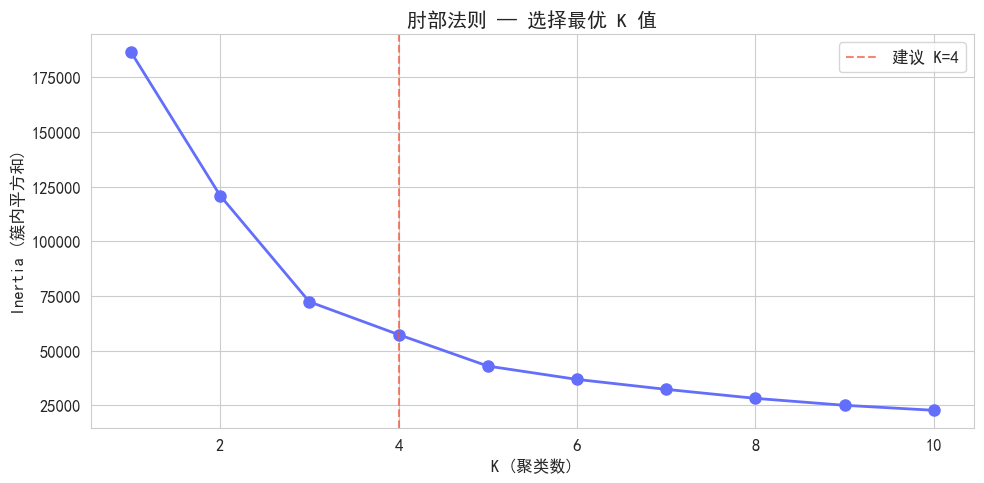

In [7]:
# 肘部法则确定最优 K 值
conn = sqlite3.connect(config.DB_PATH)
query = """
    SELECT
        c.customer_unique_id,
        julianday('2018-09-01') - julianday(MAX(o.order_purchase_timestamp)) AS recency,
        COUNT(DISTINCT o.order_id) AS frequency,
        SUM(oi.price + oi.freight_value) AS monetary
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
"""
df = pd.read_sql(query, conn)
conn.close()
features = df[['recency', 'frequency', 'monetary']]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'o-', color='#636EFA', linewidth=2, markersize=8)
plt.xlabel('K (聚类数)')
plt.ylabel('Inertia (簇内平方和)')
plt.title('肘部法则 — 选择最优 K 值')
plt.axvline(x=4, color='#EF553B', linestyle='--', alpha=0.7, label='建议 K=4')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# 聚类结果
clusters = rfm_kmeans_clustering(n_clusters=4)
cluster_summary = clusters.groupby('cluster_name').agg(
    user_count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_monetary=('monetary', 'sum')
).round(1)
cluster_summary['pct_users'] = (cluster_summary['user_count'] / len(clusters) * 100).round(1)
cluster_summary['pct_revenue'] = (cluster_summary['total_monetary'] / clusters['monetary'].sum() * 100).round(1)
cluster_summary

,user_count,avg_recency,avg_frequency,avg_monetary,total_monetary,pct_users,pct_revenue
cluster_name,,,,,,,
已流失,56045,335.2,1.0,131.5,7369604.3,60.1,49.3
高价值,37218,99.6,1.0,203.4,7568882.3,39.9,50.7


### SQL RFM vs K-Means 对比

| 维度 | SQL RFM | K-Means |
|------|---------|--------|
| 透明度 | 规则可解释 | 黑箱 |
| 灵活性 | 固定规则 | 自适应数据 |
| 面试场景 | 考察 SQL 能力 | 考察 ML 理解 |

两者互补：SQL RFM 用于业务沟通，K-Means 用于发现隐藏模式。